# Discovery — how the problems were actually found

This notebook is the **investigation**, not the finished pipeline. It exists because Part 1 of the
brief asks for *"Evidence (how you found it)"*, and a table of conclusions cannot show the moment
something looked wrong.

Four catches and three dead ends. The dead ends are here deliberately: a notebook that shows only
successful hunches is a story, not a record.

| | |
|---|---|
| **Catch 1** | An aggregate that disagreed with the rows underneath it — and inverted the Part 6 answer |
| **Catch 2** | The obvious churn label is inert |
| **Catch 3** | The strongest-looking feature family points the wrong way |
| **Catch 4** | A number I published that turned out to be my own artifact |

The hardened versions of every check below run in `scripts/01_profile.py` and are asserted in
`scripts/06_validate.py`. **Those pipeline scripts use only the standard library** so they run
anywhere; the notebooks add pandas and matplotlib purely for presentation.

In [1]:
import pandas as pd, numpy as np, os

pd.set_option("display.width", 110)
pd.set_option("display.max_columns", 30)

BASE = os.getcwd()
while not os.path.exists(os.path.join(BASE, "members.csv")) and BASE != os.path.dirname(BASE):
    BASE = os.path.dirname(BASE)

# read EVERYTHING as text: the raw files must not be silently coerced, or the
# three date formats become NaT and the evidence disappears before we see it.
members = pd.read_csv(os.path.join(BASE, "members.csv"), dtype=str, keep_default_na=False)
txns    = pd.read_csv(os.path.join(BASE, "transactions.csv"), dtype=str, keep_default_na=False)

txns["amount_n"] = pd.to_numeric(txns["amount"], errors="coerce")
txns["earned_n"] = pd.to_numeric(txns["points_earned"], errors="coerce")
txns["redeem_n"] = pd.to_numeric(txns["points_redeemed"], errors="coerce")

# transaction_date arrives in THREE formats from two exporters (finding T5/T6):
#   191,311  'YYYY-MM-DD HH:MM:SS'
#     1,500  'YYYY-MM-DD'
#     1,500  'MM/DD/YYYY'   <- a single-format parse silently NaTs these
# I hit this exact trap while writing this notebook: parsing with format="%Y-%m-%d"
# dropped 1,500 rows without raising, and the cohort came out 94 members short of
# the pipeline's. Parse both shapes explicitly, then assert nothing was lost.
iso = txns.transaction_date.str.match(r"^\d{4}-\d{2}-\d{2}")
txns["txn_date"] = pd.NaT
txns.loc[iso, "txn_date"] = pd.to_datetime(
    txns.loc[iso, "transaction_date"].str.slice(0, 10), format="%Y-%m-%d")
txns.loc[~iso, "txn_date"] = pd.to_datetime(
    txns.loc[~iso, "transaction_date"], format="%m/%d/%Y")
assert txns.txn_date.notna().all(), f"{txns.txn_date.isna().sum()} dates failed to parse"
print(f"date formats parsed: {iso.sum():,} ISO + {(~iso).sum():,} US -> 0 unparsed")

print(f"members      {len(members):>8,} rows x {members.shape[1]} cols")
print(f"transactions {len(txns):>8,} rows x {txns.shape[1] - 3} cols")
txns.head(3)

date formats parsed: 192,811 ISO + 1,500 US -> 0 unparsed
members        50,160 rows x 10 cols
transactions  194,311 rows x 10 cols


,transaction_id,member_id,transaction_date,amount,points_earned,points_redeemed,channel,brand,transaction_type,amount_n,earned_n,redeem_n,txn_date
0,T000001,M00001,2024-03-13 00:43:55,53.05,122.0,0,in_store,PulseMart,purchase,53.05,122.0,0,2024-03-13
1,T000002,M00001,2024-05-11 11:39:04,105.77,185.0,0,online,PulseEats,purchase,105.77,185.0,0,2024-05-11
2,T000003,M00001,2024-10-29 06:20:24,64.86,149.0,0,app,PulseMart,purchase,64.86,149.0,0,2024-10-29


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# Categorical palette -- validated for colour-vision deficiency separation
# (worst adjacent pair dE 9.2 deutan / 27.6 normal) against the #fcfcfb surface.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
BRAND_COLOR = {"PulseMart": BLUE, "PulseHome": ORANGE, "PulseEats": AQUA}
INK, INK2, GRID = "#0b0b0b", "#52514e", "#dcdbd6"

mpl.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "savefig.facecolor": "#fcfcfb", "figure.dpi": 110,
    "font.size": 10, "text.color": INK,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.titlecolor": INK, "axes.titlepad": 10,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": INK2, "ytick.color": INK2,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2, "lines.markersize": 8,
})

def clean_axes(ax, ygrid=True):
    """Recessive frame: no top/right spines, grid on one axis only."""
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.spines["left"].set_color(GRID)
    ax.spines["bottom"].set_color(GRID)
    ax.grid(axis="y" if ygrid else "x")
    ax.grid(axis="x" if ygrid else "y", visible=False)
    return ax

print("chart style loaded")

chart style loaded


---
## Catch 1 — the aggregate that disagreed with its own rows

Marketing claims PulseEats "gives the most points per dollar." The natural check is
`SUM(points) / SUM(amount)` per brand, so that is what I ran first.

In [3]:
raw_rate = (txns.groupby("brand")
                .apply(lambda g: g.earned_n.sum() / g.amount_n.sum(), include_groups=False)
                .sort_values(ascending=False)
                .rename("points_per_dollar")
                .to_frame())
raw_rate

,points_per_dollar
brand,
PulseHome,1.948291
PulseEats,1.746262
PulseMart,0.905744


So PulseHome wins, marketing is wrong, done in three minutes.

Except **0.906 is not a plausible number.** A brand paying 0.9 points per dollar while its siblings
pay ~2 is a strategy, not an accident, and nothing else in the data suggested PulseMart was positioned
differently. Before writing that down, I looked at what individual PulseMart transactions actually pay.

In [4]:
pm = txns[(txns.brand == "PulseMart") & (txns.amount_n > 0) & txns.earned_n.notna()]
per_txn = (pm.earned_n / pm.amount_n).describe(percentiles=[.1, .5, .9])
print(per_txn[["count", "10%", "50%", "90%"]].to_string())
print(f"\naggregate said {raw_rate.loc['PulseMart', 'points_per_dollar']:.3f}, "
      f"but the TYPICAL row pays {(pm.earned_n / pm.amount_n).median():.2f}")
print("An aggregate cannot sit below its own 10th percentile unless the denominator is contaminated.")

count    64039.000000
10%          2.290813
50%          2.300034
90%          2.309100

aggregate said 0.906, but the TYPICAL row pays 2.30
An aggregate cannot sit below its own 10th percentile unless the denominator is contaminated.


That settles it: the rows are fine, the denominator is poisoned. Sort by amount, largest first.

In [5]:
big = txns.nlargest(15, "amount_n")[["transaction_id", "brand", "amount_n", "earned_n"]]
print(f"p99 of amount = ${txns.amount_n.quantile(0.99):,.2f}")
print(f"these 15 rows carry ${big.amount_n.sum():,.2f} of fake spend "
      f"(~{big.amount_n.max()/txns.amount_n.quantile(0.99):,.0f}x p99)\n")
print(big.brand.value_counts().to_string())
big

p99 of amount = $285.71
these 15 rows carry $6,827,882.44 of fake spend (~3,500x p99)

brand
PulseMart    12
PulseHome     2
PulseEats     1


,transaction_id,brand,amount_n,earned_n
189313,TO00000,PulseMart,999999.99,119.0
189314,TO00001,PulseMart,999999.99,131.0
189315,TO00002,PulseMart,999999.99,108.0
189316,TO00003,PulseMart,999999.99,83.0
189317,TO00004,PulseMart,999999.99,106.0
189318,TO00005,PulseMart,999999.99,121.0
189319,TO00006,PulseMart,99999.00,147.0
189320,TO00007,PulseMart,99999.00,109.0
189321,TO00008,PulseMart,99999.00,112.0
189322,TO00009,PulseMart,99999.00,148.0


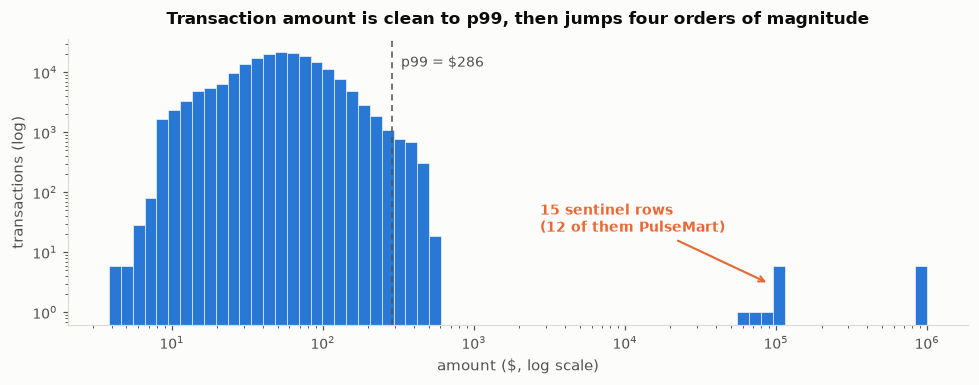

In [6]:
fig, ax = plt.subplots(figsize=(9, 3.6))
vals = txns.amount_n.dropna()
bins = np.logspace(np.log10(max(vals[vals > 0].min(), 0.01)), np.log10(vals.max()), 70)
ax.hist(vals[vals > 0], bins=bins, color=BLUE, edgecolor="#fcfcfb", linewidth=0.4)
ax.set_xscale("log"); ax.set_yscale("log")
clean_axes(ax)
p99 = vals.quantile(0.99)
ax.axvline(p99, color=INK2, linewidth=1, linestyle=(0, (4, 3)))
ax.annotate(f"p99 = ${p99:,.0f}", xy=(p99, ax.get_ylim()[1] * 0.35),
            xytext=(6, 0), textcoords="offset points", color=INK2, fontsize=9)
ax.annotate("15 sentinel rows\n(12 of them PulseMart)",
            xy=(9e4, 3), xytext=(-150, 34), textcoords="offset points",
            color=ORANGE, fontsize=9, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=ORANGE, linewidth=1.4))
ax.set_title("Transaction amount is clean to p99, then jumps four orders of magnitude")
ax.set_xlabel("amount ($, log scale)"); ax.set_ylabel("transactions (log)")
plt.tight_layout(); plt.show()

In [7]:
# recompute with duplicates, refunds and sentinels excluded
d = txns.drop_duplicates("transaction_id")
ok = d[(d.amount_n > 0) & (d.amount_n < 9999) & d.earned_n.notna()]
cleaned = ok.groupby("brand").apply(lambda g: g.earned_n.sum()/g.amount_n.sum(),
                                    include_groups=False).rename("cleaned")
cmp = raw_rate.join(cleaned).rename(columns={"points_per_dollar": "raw"})
cmp["rank_raw"] = cmp["raw"].rank(ascending=False).astype(int)
cmp["rank_clean"] = cmp["cleaned"].rank(ascending=False).astype(int)
cmp.round(3)

,raw,cleaned,rank_raw,rank_clean
brand,,,,
PulseHome,1.948,2.00,1,2
PulseEats,1.746,1.75,2,3
PulseMart,0.906,2.30,3,1


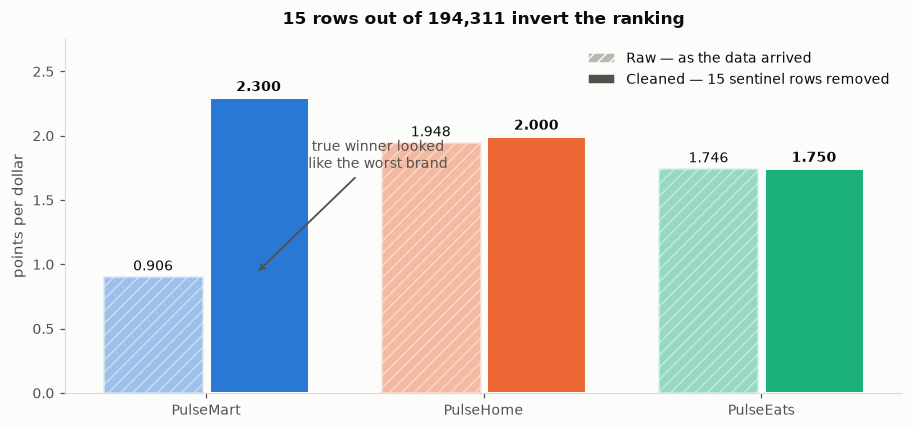

Raw ranking:    PulseHome > PulseEats > PulseMart
Cleaned ranking:PulseMart > PulseHome > PulseEats


In [8]:
order = ["PulseMart", "PulseHome", "PulseEats"]
fig, ax = plt.subplots(figsize=(8.4, 4))
x = np.arange(len(order)); w = 0.36
for i, (col, hatch, label) in enumerate([("raw", "///", "Raw — as the data arrived"),
                                         ("cleaned", None, "Cleaned — 15 sentinel rows removed")]):
    vals = [cmp.loc[b, col] for b in order]
    bars = ax.bar(x + (i - 0.5) * (w + 0.02), vals, w,
                  color=[BRAND_COLOR[b] for b in order],
                  alpha=1.0 if col == "cleaned" else 0.45,
                  hatch=hatch, edgecolor="#fcfcfb", linewidth=2, label=label)
    for b_, v in zip(bars, vals):                      # direct labels on every bar
        ax.annotate(f"{v:.3f}", (b_.get_x() + b_.get_width()/2, v), (0, 4),
                    textcoords="offset points", ha="center", fontsize=9,
                    color=INK, fontweight="bold" if col == "cleaned" else "normal")
clean_axes(ax)
# colour identifies the BRAND; texture identifies raw vs cleaned. A coloured legend
# swatch here would wrongly imply "blue = raw", so the swatches are neutral.
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor="#b8b7b1", hatch="///", edgecolor="#fcfcfb", label="Raw — as the data arrived"),
    Patch(facecolor="#52514e", edgecolor="#fcfcfb", label="Cleaned — 15 sentinel rows removed"),
]
ax.set_xticks(x); ax.set_xticklabels(order)
ax.set_ylabel("points per dollar"); ax.set_ylim(0, 2.75)
ax.set_title("15 rows out of 194,311 invert the ranking")
ax.legend(handles=legend_handles, loc="upper right", ncols=1)
ax.annotate("true winner looked\nlike the worst brand", xy=(0.18, 0.93), xytext=(0.62, 1.75),
            color=INK2, fontsize=9, ha="center",
            arrowprops=dict(arrowstyle="->", color=INK2, linewidth=1.2))
plt.tight_layout(); plt.show()
print("Raw ranking:    " + " > ".join(cmp.sort_values('raw', ascending=False).index))
print("Cleaned ranking:" + " > ".join(cmp.sort_values('cleaned', ascending=False).index))

**Lesson kept:** when an aggregate disagrees with the rows underneath it, the aggregate is wrong.
This one mattered — the naive number produces a confidently incorrect answer to Part 6.

---
## Catch 2 — the obvious churn label is inert

`members.csv` has a `status` column: `active` / `inactive` / `churned`. Using it as the model target
is the obvious move and produces clean code. Before doing that, I checked whether the labels agree
with observed behaviour.

In [9]:
last = txns.groupby("member_id").txn_date.max().rename("last_txn")
mem = members.merge(last, left_on="member_id", right_index=True, how="left")

summary = (mem.dropna(subset=["last_txn"])
              .groupby("status")
              .last_txn.agg(n="size", median="median", latest="max"))
summary

,n,median,latest
status,,,
active,35069,2026-04-06,2026-06-30
churned,5096,2026-04-04,2026-06-30
inactive,9981,2026-04-05,2026-06-30


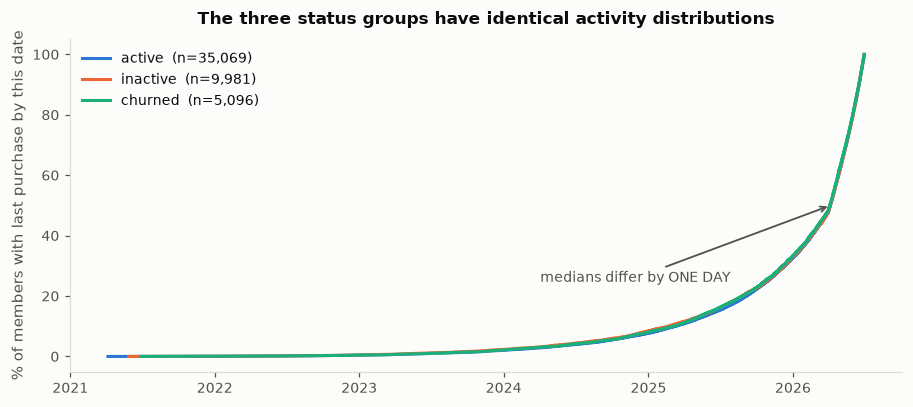

status
active     2026-04-06
churned    2026-04-04
inactive   2026-04-05

`status` carries no activity information. It cannot be the target.


In [10]:
fig, ax = plt.subplots(figsize=(8.4, 3.8))
for status, color in [("active", BLUE), ("inactive", ORANGE), ("churned", AQUA)]:
    s = mem.loc[mem.status == status, "last_txn"].dropna().sort_values()
    ax.plot(s.values, np.linspace(0, 100, len(s)), color=color, label=f"{status}  (n={len(s):,})")
clean_axes(ax)
ax.set_ylabel("% of members with last purchase by this date")
ax.set_title("The three status groups have identical activity distributions")
ax.legend(loc="upper left")
med = summary["median"]
ax.annotate("medians differ by ONE DAY", xy=(med.iloc[0], 50), xytext=(-190, -50),
            textcoords="offset points", color=INK2, fontsize=9,
            arrowprops=dict(arrowstyle="->", color=INK2, linewidth=1.2))
plt.tight_layout(); plt.show()
print(summary["median"].to_string())
print("\n`status` carries no activity information. It cannot be the target.")

The curves lie on top of each other. Nothing in a code review would have caught this — the SQL would
have been perfectly valid. It only surfaces if you ask whether the *labels* mean anything.

The label is therefore defined behaviourally: **no purchase in the 90 days after a cutoff `T`**.

---
## Catch 3 — the strongest-looking feature points the wrong way

RFM is the textbook answer, and transaction count looked like the best feature in the set.

In [11]:
MAX = txns.txn_date.max()
T   = MAX - pd.Timedelta(days=90)

# match the pipeline exactly: dedupe on transaction_id (T1) and drop orphan
# member_ids (T7), or the cohort size and base rate will not agree with the write-up
valid = (txns.drop_duplicates("transaction_id")
             .loc[lambda d: d.member_id.isin(set(members.member_id))])
print(f"after dedup + orphan removal: {len(valid):,} of {len(txns):,} rows")

before = valid[valid.txn_date <= T]
after  = set(valid.loc[valid.txn_date > T, "member_id"])

feat = before.groupby("member_id").agg(txns_before=("transaction_id", "size"),
                                       last_txn=("txn_date", "max"))
feat["recency"] = (T - feat.last_txn).dt.days
feat["churned"] = (~feat.index.isin(after)).astype(int)
cohort = feat[feat.recency <= 365]
print(f"cutoff T = {T.date()}   cohort = {len(cohort):,}   base rate = {100*cohort.churned.mean():.1f}%")

by_ct = (cohort.assign(bucket=cohort.txns_before.clip(upper=6))
               .groupby("bucket").churned.agg(n="size", churn_rate="mean"))
by_ct["churn_rate"] = (100 * by_ct.churn_rate).round(1)
by_ct

after dedup + orphan removal: 189,328 of 194,311 rows
cutoff T = 2026-04-01   cohort = 31,712   base rate = 58.8%


,n,churn_rate
bucket,,
1,2116,27.7
2,4351,46.1
3,6500,56.6
4,6736,62.1
5,5389,66.1
6,6620,70.3


A 36-point spread — stronger separation than recency, and it would sail through any lift-based check.

**But read the direction.** It says *the more someone buys, the more likely they are to churn.* That
is backwards. So: real behaviour, or artifact?

In [12]:
after_ct = valid[valid.txn_date > T].groupby("member_id").size()
both = pd.DataFrame({"before": feat.txns_before}).join(after_ct.rename("after")).fillna(0)
r = both.before.corr(both["after"])
total = (both.before + both["after"])
print(f"corr(transactions BEFORE cutoff, transactions AFTER cutoff) = {r:+.3f}")
print("\nreal customer behaviour => POSITIVE (frequent buyers keep buying)")
print(f"measured                => NEGATIVE")
print(f"\ntotal transactions per member: median={total.median():.0f}, max={total.max():.0f}")
print("=> members carry a near-fixed lifetime transaction budget, so a purchase seen")
print("   before the cutoff is one SPENT. Every volume-accumulating feature inherits this.")

corr(transactions BEFORE cutoff, transactions AFTER cutoff) = -0.217

real customer behaviour => POSITIVE (frequent buyers keep buying)
measured                => NEGATIVE

total transactions per member: median=4, max=16
=> members carry a near-fixed lifetime transaction budget, so a purchase seen
   before the cutoff is one SPENT. Every volume-accumulating feature inherits this.


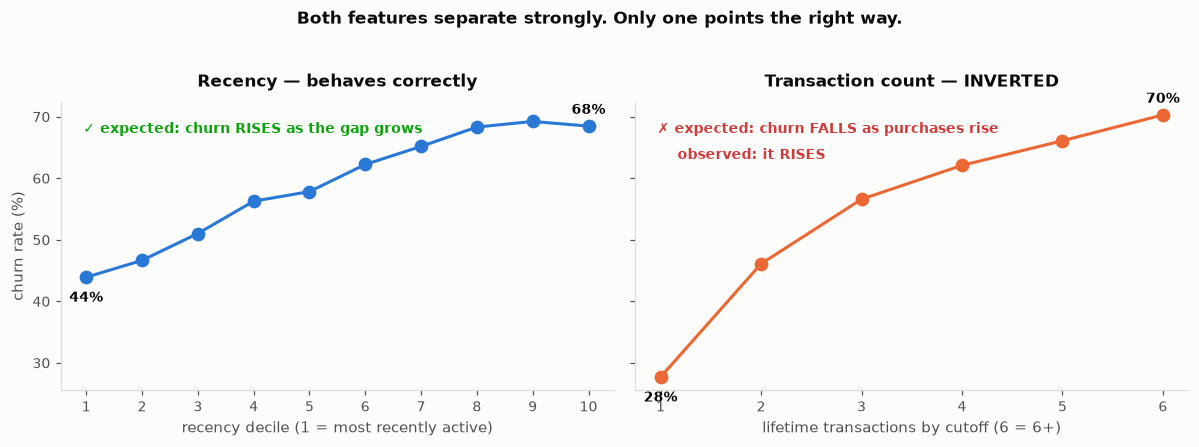

In [13]:
rec_dec = (cohort.assign(d=pd.qcut(cohort.recency, 10, labels=False, duplicates="drop"))
                 .groupby("d").churned.mean() * 100)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.9), sharey=True)
a = axes[0]
a.plot(rec_dec.index + 1, rec_dec.values, color=BLUE, marker="o")
clean_axes(a)
a.set_title("Recency — behaves correctly")
a.set_xlabel("recency decile (1 = most recently active)")
a.set_ylabel("churn rate (%)"); a.set_xticks(range(1, 11))
a.annotate(f"{rec_dec.iloc[0]:.0f}%", (1, rec_dec.iloc[0]), (0, -16),
           textcoords="offset points", ha="center", color=INK, fontsize=9, fontweight="bold")
a.annotate(f"{rec_dec.iloc[-1]:.0f}%", (10, rec_dec.iloc[-1]), (0, 8),
           textcoords="offset points", ha="center", color=INK, fontsize=9, fontweight="bold")

b = axes[1]
b.plot(by_ct.index, by_ct.churn_rate.values, color=ORANGE, marker="o")
clean_axes(b)
b.set_title("Transaction count — INVERTED"); b.set_xlabel("lifetime transactions by cutoff (6 = 6+)")
b.annotate(f"{by_ct.churn_rate.iloc[0]:.0f}%", (by_ct.index[0], by_ct.churn_rate.iloc[0]),
           (0, -16), textcoords="offset points", ha="center", color=INK, fontsize=9, fontweight="bold")
b.annotate(f"{by_ct.churn_rate.iloc[-1]:.0f}%", (by_ct.index[-1], by_ct.churn_rate.iloc[-1]),
           (0, 8), textcoords="offset points", ha="center", color=INK, fontsize=9, fontweight="bold")
# both lines slope up, so the failure is NOT visible from shape -- say it outright
a.text(0.04, 0.93, "✓ expected: churn RISES as the gap grows", transform=a.transAxes,
       fontsize=9, fontweight="bold", color="#0ca30c", va="top")
b.text(0.04, 0.93, "✗ expected: churn FALLS as purchases rise", transform=b.transAxes,
       fontsize=9, fontweight="bold", color="#d03b3b", va="top")
b.text(0.04, 0.84, "    observed: it RISES", transform=b.transAxes,
       fontsize=9, fontweight="bold", color="#d03b3b", va="top")
fig.suptitle("Both features separate strongly. Only one points the right way.",
             fontsize=11, fontweight="bold", y=1.03)
plt.tight_layout(); plt.show()

**Lesson kept:** validate *direction* before *strength*. A feature can be highly predictive and still
be a trap — this one would have inverted a retention budget while scoring beautifully in validation.

---
## Catch 4 — a number I published that was my own artifact

Writing Part 8, I reported that **21 members hold negative point balances** and used it as evidence
that the source ledger is incomplete. The number felt large for a dataset this otherwise-regular, so
I re-derived it with my own refund correction switched off.

In [14]:
d = txns.drop_duplicates("transaction_id")
d = d[d.member_id.isin(set(members.member_id))].copy()
d["earned_f"] = d.earned_n.fillna(0)
# our cleaning zeroes points wrongly granted on refunds (amount < 0)
d["earned_after_fix"] = np.where(d.amount_n < 0, 0.0, d.earned_f)

bal = d.groupby("member_id").agg(src=("earned_f", "sum"),
                                 fixed=("earned_after_fix", "sum"),
                                 redeemed=("redeem_n", "sum"))
src_neg  = int((bal.src   - bal.redeemed < 0).sum())
post_neg = int((bal.fixed - bal.redeemed < 0).sum())
print(f"negative balances in the SOURCE data        : {src_neg}")
print(f"negative balances AFTER our refund reversal : {post_neg}")
print(f"created by our own fix                      : {post_neg - src_neg}")
print(f"\nI had published {post_neg} as proof that SOMEONE ELSE's ledger is broken.")
print(f"Only {src_neg} of them are. The honest number is {src_neg}.")

negative balances in the SOURCE data        : 5
negative balances AFTER our refund reversal : 21
created by our own fix                      : 16

I had published 21 as proof that SOMEONE ELSE's ledger is broken.
Only 5 of them are. The honest number is 5.


This is the mistake I would most want a reviewer to see caught, because it happened *inside* the
section headed "reasons to distrust my own number." The corrected claim is now asserted in
`scripts/06_validate.py` — including a check on the wording in the write-up — so it cannot drift back.

The 16 are still informative: those members redeemed points that the refund correction says they
never legitimately earned. But that is a different sentence with a different meaning.

---
## Dead ends

Checks that found nothing. Recorded because "I looked and it was fine" is evidence too.

In [15]:
# (a) do earn rates differ by tier or channel? (tiers usually matter in loyalty schemes)
d2 = txns.drop_duplicates("transaction_id")
d2 = d2[(d2.amount_n > 0) & (d2.amount_n < 9999) & d2.earned_n.notna()]
tier = members.drop_duplicates("member_id").set_index("member_id").tier.str.strip().str.title()
d2 = d2.assign(tier=d2.member_id.map(tier))

for dim in ("tier", "channel"):
    t = (d2.groupby(["brand", dim])
           .apply(lambda g: g.earned_n.sum()/g.amount_n.sum(), include_groups=False)
           .unstack().round(3))
    if dim == "tier":
        t = t[["Bronze", "Silver", "Gold", "Platinum"]]
    print(f"points per dollar by brand x {dim}:")
    print(t.to_string(), "\n")
print("Identical to 3 dp everywhere. Not the bug I was hunting -- but it became a")
print("PRODUCT finding: Platinum earns exactly what Bronze earns, so the top tier")
print("confers no earning advantage at all.")

points per dollar by brand x tier:
tier       Bronze  Silver  Gold  Platinum
brand                                    
PulseEats    1.75    1.75  1.75      1.75
PulseHome    2.00    2.00  2.00      2.00
PulseMart    2.30    2.30  2.30      2.30 

points per dollar by brand x channel:
channel     app  in_store  online
brand                            
PulseEats  1.75      1.75    1.75
PulseHome  2.00      2.00    2.00
PulseMart  2.30      2.30    2.30 

Identical to 3 dp everywhere. Not the bug I was hunting -- but it became a
PRODUCT finding: Platinum earns exactly what Bronze earns, so the top tier
confers no earning advantage at all.


In [16]:
# (b) impossible ages? loyalty files often carry placeholder or under-age DOBs
bd = pd.to_datetime(members.birth_date, format="%Y-%m-%d", errors="coerce").dropna()
age = ((pd.Timestamp("2026-09-10") - bd).dt.days // 365)
print(f"ages: min={age.min()}  median={age.median():.0f}  max={age.max()}")
print(f"under 18: {(age < 18).sum()}    over 90: {(age > 90).sum()}")
print("Clean. No placeholder DOBs, no impossible ages. Nothing to report.")

ages: min=19  median=40  max=61
under 18: 0    over 90: 0
Clean. No placeholder DOBs, no impossible ages. Nothing to report.


In [17]:
# (c) gaps in the transaction timeline -- would reveal a historic feed outage
days = pd.Series(sorted(txns.txn_date.dropna().dt.normalize().unique()))
full = pd.date_range(days.min(), days.max(), freq="D")
missing = full.difference(pd.DatetimeIndex(days))
runs = (pd.Series(missing).diff().dt.days.ne(1).cumsum().value_counts().sort_values(ascending=False))
print(f"span {days.min().date()} .. {days.max().date()}  "
      f"({len(full):,} days, {len(days):,} with data)")
print(f"days with zero transactions: {len(missing)}  "
      f"(by year: {dict(pd.Series(missing).dt.year.value_counts().sort_index())})")
print(f"longest consecutive gap: {runs.iloc[0]} days")
print("\nAll in 2021, when the base was small. Benign -- but nothing in the current process")
print("would have noticed a multi-day hole, so it became a blocking check in the Part 3 design.")

span 2021-01-05 .. 2026-06-30  (2,003 days, 1,984 with data)
days with zero transactions: 19  (by year: {2021: np.int64(19)})
longest consecutive gap: 5 days

All in 2021, when the base was small. Benign -- but nothing in the current process
would have noticed a multi-day hole, so it became a blocking check in the Part 3 design.


---
## Where this goes

| Catch | Lands in |
|---|---|
| Sentinel rows inverting points-per-dollar | Part 1 (T2), Part 6 |
| `status` is inert | Part 1 (M8), Part 2 label definition |
| Frequency runs backwards | Part 2 "features I'd be nervous shipping" |
| 21 vs 5 negative balances | Part 8, and an assertion in `06_validate.py` |
| Tier/channel invariance | Part 6 product finding, Part 2 tier caveat |
| Timeline gaps | Part 3 blocking DQ checks |

Continue to **`01_feature_build.ipynb`** for how these findings become cleaning and feature decisions.